# Holdout AUROC — Cross-Dataset LR Classifier Evaluations

Loads all `eval_results_classifier_*.json` files from
`/home/ines/Reasoning-activations/results/lr_classifier_<train>/eval_<eval>/`
and plots AUROC across layers for every (train dataset, eval dataset, LR granularity, eval granularity) combination in a single figure.

In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

## 1. Discover and load all eval JSON files

In [2]:
RESULTS_ROOT = Path("/home/ines/Reasoning-activations/results")

# Pattern: results/lr_classifier_<TRAIN>/eval_<EVAL>/eval_results_classifier_*.json
json_files = sorted(RESULTS_ROOT.glob("lr_classifier_*/eval_*/eval_results_classifier_*.json"))

print(f"Found {len(json_files)} eval JSON file(s):")
for p in json_files:
    print(" ", p.relative_to(RESULTS_ROOT))

Found 2 eval JSON file(s):
  lr_classifier_math_shepherd/eval_processbench/eval_results_classifier_processbench.json
  lr_classifier_processbench/eval_math_shepherd/eval_results_classifier_math_shepherd.json


In [3]:
def parse_tags_from_path(path: Path):
    """Extract train/eval dataset tags from the directory path."""
    # Try directory names first (most reliable)
    parts = path.parts
    train_tag, eval_tag = None, None

    for part in parts:
        m = re.match(r"lr_classifier_(.+)", part)
        if m:
            train_tag = m.group(1)
        m = re.match(r"eval_(.+)", part)
        if m:
            eval_tag = m.group(1)

    # Fall back to config fields inside the JSON
    return train_tag, eval_tag


def load_eval_file(path: Path):
    """Load one JSON and return a structured record."""
    with open(path) as f:
        data = json.load(f)

    train_tag, eval_tag = parse_tags_from_path(path)

    # Also try to read from config if directory parse failed
    cfg = data.get("config", {})
    if not train_tag:
        m = re.search(r"/lr_classifier_([^/]+)/lr_learned_weights",
                      cfg.get("lr_weights_file", ""))
        train_tag = m.group(1) if m else "unknown_train"
    if not eval_tag:
        m = re.search(r"/Qwen3-8B/([^/]+)/reasoning_vectors_",
                      cfg.get("activations_file", ""))
        eval_tag = m.group(1) if m else "unknown_eval"

    metrics = data.get("classifier_metrics", {})

    # Parse keys: "{lr_gran}__layer{N}__eval_{eval_gran}"
    parsed = []
    for key, vals in metrics.items():
        m = re.match(r"(.+)__layer(\d+)__eval_(.+)", key)
        if not m:
            continue
        parsed.append({
            "train_tag":  train_tag,
            "eval_tag":   eval_tag,
            "lr_gran":    m.group(1),
            "layer":      int(m.group(2)),
            "eval_gran":  m.group(3),
            "auroc":      vals.get("auroc"),
            "accuracy":   vals.get("accuracy"),
            "f1":         vals.get("f1"),
            "n_pos":      vals.get("n_pos"),
            "n_neg":      vals.get("n_neg"),
        })

    return parsed


all_records = []
for p in json_files:
    records = load_eval_file(p)
    all_records.extend(records)
    print(f"  Loaded {len(records):3d} entries from {p.name}  "
          f"(train={records[0]['train_tag']}, eval={records[0]['eval_tag']})" if records else f"  Empty: {p}")

print(f"\nTotal entries: {len(all_records)}")

  Loaded  44 entries from eval_results_classifier_processbench.json  (train=math_shepherd, eval=results_classifier_processbench.json)
  Loaded  44 entries from eval_results_classifier_math_shepherd.json  (train=processbench, eval=results_classifier_math_shepherd.json)

Total entries: 88


## 2. Organise into a nested dict for easy lookup

In [4]:
from collections import defaultdict

# Index: (train_tag, eval_tag, lr_gran, eval_gran) -> {layer: auroc}
auroc_by_combo = defaultdict(dict)

for r in all_records:
    key = (r["train_tag"], r["eval_tag"], r["lr_gran"], r["eval_gran"])
    auroc_by_combo[key][r["layer"]] = r["auroc"]

# Collect unique values for plot axes
train_tags  = sorted({r["train_tag"]  for r in all_records})
eval_tags   = sorted({r["eval_tag"]   for r in all_records})
lr_grans    = sorted({r["lr_gran"]    for r in all_records})
eval_grans  = sorted({r["eval_gran"]  for r in all_records})
all_layers  = sorted({r["layer"]      for r in all_records})

print("Train datasets :", train_tags)
print("Eval  datasets :", eval_tags)
print("LR granularities :", lr_grans)
print("Eval granularities:", eval_grans)
print("Layers           :", all_layers)

Train datasets : ['math_shepherd', 'processbench']
Eval  datasets : ['results_classifier_math_shepherd.json', 'results_classifier_processbench.json']
LR granularities : ['sample', 'step']
Eval granularities: ['sample', 'step']
Layers           : [18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]


## 3. Plot AUROC across layers — all holdout evaluations

In [5]:
# ── Colour palette ────────────────────────────────────────────────────────────
# Each (train_tag, eval_tag) pair gets a distinct colour; lr_gran sets linestyle.

PALETTE = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
    "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
]
LINESTYLES = {"step": "-", "sample": "--", "token": ":"}
MARKERS    = {"step": "s",  "sample": "D",   "token": "o"}

# Build all (train, eval) pairs that are actually present
cross_pairs = sorted({(r["train_tag"], r["eval_tag"]) for r in all_records})
pair_colors = {pair: PALETTE[i % len(PALETTE)] for i, pair in enumerate(cross_pairs)}

print("Cross-dataset pairs to plot:")
for pair, col in pair_colors.items():
    print(f"  train={pair[0]:20s}  eval={pair[1]:20s}  color={col}")

Cross-dataset pairs to plot:
  train=math_shepherd         eval=results_classifier_processbench.json  color=#1f77b4
  train=processbench          eval=results_classifier_math_shepherd.json  color=#ff7f0e


Saved → /home/ines/Reasoning-activations/results/holdout_auroc_all_evals.png


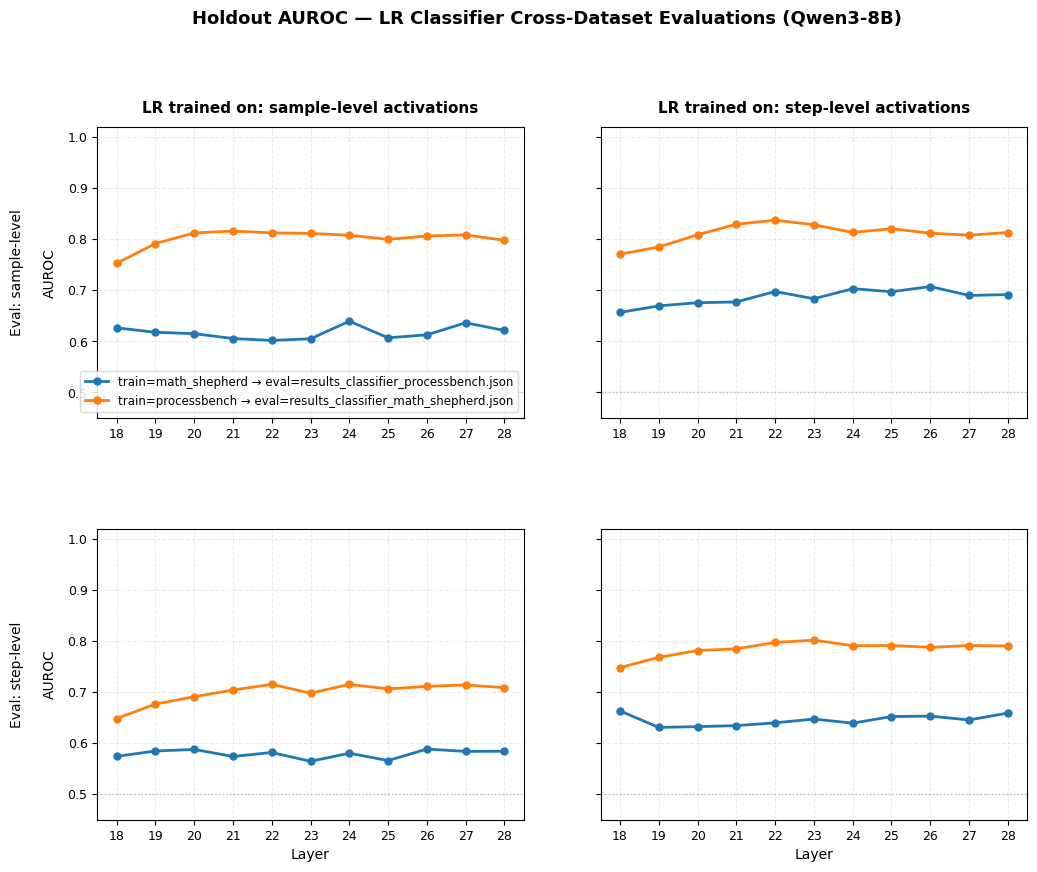

In [6]:
def make_auroc_grid(
    auroc_by_combo,
    all_layers,
    lr_grans,
    eval_grans,
    cross_pairs,
    pair_colors,
    title="Holdout AUROC — LR Classifier Cross-Dataset Evaluations",
    save_path=None,
):
    """
    Grid layout:
      rows    = eval granularities  (step / sample)
      columns = LR granularities    (step / sample)

    Each panel shows AUROC vs layer for every (train, eval) dataset pair.
    """
    n_rows = len(eval_grans)
    n_cols = len(lr_grans)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(6 * n_cols, 4.5 * n_rows),
        squeeze=False,
        sharey=True,
    )
    plt.subplots_adjust(hspace=0.38, wspace=0.18)

    for row_i, eval_gran in enumerate(eval_grans):
        for col_i, lr_gran in enumerate(lr_grans):
            ax = axes[row_i, col_i]

            for (train_tag, eval_tag) in cross_pairs:
                key = (train_tag, eval_tag, lr_gran, eval_gran)
                layer_auroc = auroc_by_combo.get(key, {})
                if not layer_auroc:
                    continue

                layers_sorted = sorted(layer_auroc)
                aurocs        = [layer_auroc[l] for l in layers_sorted]

                label = f"train={train_tag} → eval={eval_tag}"
                color = pair_colors[(train_tag, eval_tag)]

                ax.plot(
                    layers_sorted, aurocs,
                    color=color,
                    linewidth=2.0,
                    marker="o",
                    markersize=5,
                    label=label,
                    zorder=3,
                )

            # ── Formatting ────────────────────────────────────────────────
            ax.axhline(0.5, color="gray", linestyle=":", linewidth=1.0, alpha=0.5, zorder=1)
            ax.set_ylim(0.45, 1.02)
            ax.set_xlim(min(all_layers) - 0.5, max(all_layers) + 0.5)
            ax.set_xticks(all_layers)
            ax.tick_params(axis="x", labelsize=9)
            ax.tick_params(axis="y", labelsize=9)
            ax.grid(True, alpha=0.25, linestyle="--")

            # Column header (top row only)
            if row_i == 0:
                ax.set_title(
                    f"LR trained on: {lr_gran}-level activations",
                    fontsize=11, fontweight="bold", pad=10,
                )

            # Row label (left column only)
            if col_i == 0:
                ax.set_ylabel(
                    f"Eval: {eval_gran}-level\n\nAUROC",
                    fontsize=10, labelpad=8,
                )

            # X-axis label (bottom row only)
            if row_i == n_rows - 1:
                ax.set_xlabel("Layer", fontsize=10)

            # Legend (first panel only to avoid clutter)
            if row_i == 0 and col_i == 0:
                ax.legend(
                    fontsize=8.5,
                    loc="lower right",
                    framealpha=0.85,
                    edgecolor="lightgray",
                )

    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.01)

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Saved → {save_path}")

    plt.show()
    return fig


fig = make_auroc_grid(
    auroc_by_combo,
    all_layers,
    lr_grans,
    eval_grans,
    cross_pairs,
    pair_colors,
    title="Holdout AUROC — LR Classifier Cross-Dataset Evaluations (Qwen3-8B)",
    save_path=RESULTS_ROOT / "holdout_auroc_all_evals.png",
)

## 4. Alternative: flat view — one panel per (train→eval) pair

Saved → /home/ines/Reasoning-activations/results/holdout_auroc_per_pair.png


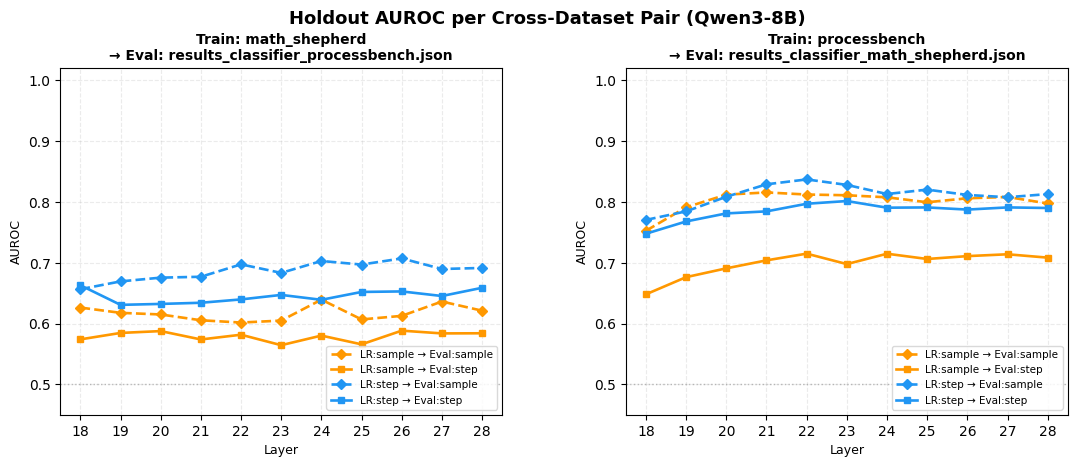

In [7]:
def make_auroc_per_pair(
    auroc_by_combo,
    all_layers,
    lr_grans,
    eval_grans,
    cross_pairs,
    save_path=None,
):
    """
    One subplot per (train, eval) pair.
    Within each subplot: lines for every (lr_gran, eval_gran) combination.
    """
    n_pairs = len(cross_pairs)
    n_cols  = min(3, n_pairs)
    n_rows  = (n_pairs + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(6.5 * n_cols, 4.5 * n_rows),
        squeeze=False,
    )
    plt.subplots_adjust(hspace=0.42, wspace=0.28)

    # One colour per lr_gran, one linestyle per eval_gran
    lr_colors = {"step": "#2196F3", "sample": "#FF9800", "token": "#4CAF50"}
    eg_ls     = {"step": "-",       "sample": "--",      "token": ":"}
    eg_mk     = {"step": "s",       "sample": "D",       "token": "o"}

    for idx, (train_tag, eval_tag) in enumerate(cross_pairs):
        row, col = divmod(idx, n_cols)
        ax = axes[row][col]

        for lr_gran in lr_grans:
            for eval_gran in eval_grans:
                key = (train_tag, eval_tag, lr_gran, eval_gran)
                layer_auroc = auroc_by_combo.get(key, {})
                if not layer_auroc:
                    continue

                layers_sorted = sorted(layer_auroc)
                aurocs        = [layer_auroc[l] for l in layers_sorted]

                ax.plot(
                    layers_sorted, aurocs,
                    color=lr_colors.get(lr_gran, "gray"),
                    linestyle=eg_ls.get(eval_gran, "-"),
                    marker=eg_mk.get(eval_gran, "o"),
                    markersize=5,
                    linewidth=1.9,
                    label=f"LR:{lr_gran} → Eval:{eval_gran}",
                    zorder=3,
                )

        ax.axhline(0.5, color="gray", linestyle=":", linewidth=1.0, alpha=0.5)
        ax.set_ylim(0.45, 1.02)
        ax.set_xlim(min(all_layers) - 0.5, max(all_layers) + 0.5)
        ax.set_xticks(all_layers)
        ax.set_xlabel("Layer", fontsize=9)
        ax.set_ylabel("AUROC",  fontsize=9)
        ax.grid(True, alpha=0.25, linestyle="--")
        ax.set_title(
            f"Train: {train_tag}\n→ Eval: {eval_tag}",
            fontsize=10, fontweight="bold",
        )
        ax.legend(fontsize=7.5, loc="lower right", framealpha=0.85, edgecolor="lightgray")

    # Hide unused panels
    for idx in range(n_pairs, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        axes[row][col].set_visible(False)

    fig.suptitle(
        "Holdout AUROC per Cross-Dataset Pair (Qwen3-8B)",
        fontsize=13, fontweight="bold", y=1.01,
    )

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Saved → {save_path}")

    plt.show()
    return fig


fig2 = make_auroc_per_pair(
    auroc_by_combo,
    all_layers,
    lr_grans,
    eval_grans,
    cross_pairs,
    save_path=RESULTS_ROOT / "holdout_auroc_per_pair.png",
)

## 5. Summary table — best layer AUROC per combination

In [8]:
import pandas as pd

rows = []
for (train_tag, eval_tag, lr_gran, eval_gran), layer_auroc in auroc_by_combo.items():
    if not layer_auroc:
        continue
    best_layer = max(layer_auroc, key=layer_auroc.get)
    best_auroc = layer_auroc[best_layer]
    rows.append({
        "Train dataset":    train_tag,
        "Eval dataset":     eval_tag,
        "LR granularity":   lr_gran,
        "Eval granularity": eval_gran,
        "Best layer":       best_layer,
        "Best AUROC":       round(best_auroc, 4),
    })

df = pd.DataFrame(rows).sort_values(
    ["Train dataset", "Eval dataset", "LR granularity", "Eval granularity"]
).reset_index(drop=True)

pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)
print(df.to_string(index=False))

Train dataset                          Eval dataset LR granularity Eval granularity  Best layer  Best AUROC
math_shepherd  results_classifier_processbench.json         sample           sample          24      0.6393
math_shepherd  results_classifier_processbench.json         sample             step          26      0.5883
math_shepherd  results_classifier_processbench.json           step           sample          26      0.7071
math_shepherd  results_classifier_processbench.json           step             step          18      0.6630
 processbench results_classifier_math_shepherd.json         sample           sample          21      0.8157
 processbench results_classifier_math_shepherd.json         sample             step          22      0.7150
 processbench results_classifier_math_shepherd.json           step           sample          22      0.8371
 processbench results_classifier_math_shepherd.json           step             step          23      0.8015
